# Problem Set 5: Misspecification in a Rust-Style Replacement Model

(Solutions)

David Evans  
2026-05-26

# Building the Model

## Problem 1: The `VanModel` Struct

**(a)** The struct mirrors `RustModel` but stores a single quadratic
coefficient $\theta_2$ and pre-computes a pure-quadratic cost vector.

In [1]:
@kwdef struct VanModel
    β::Float64 = 0.95
    S::Int = 50
    RC::Float64 = 20.0
    θ₂::Float64 = 0.001078
    θ₃::Vector{Float64} = [0.36, 0.48, 0.16]
    x̄::Vector{Float64} = Float64.(0:S-1)
    c::Vector{Float64} = θ₂ .* (x̄ .^ 2)
end

VanModel

**(b)** Plot the true cost and its OLS-through-origin linear
approximation.


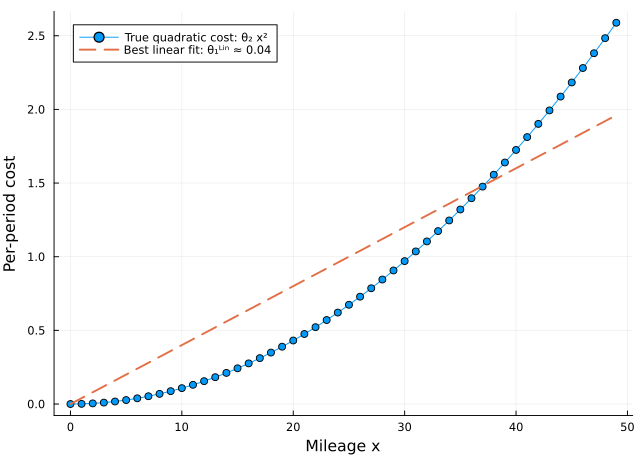

In [1]:
m = VanModel()
(; x̄, c, S, β, RC, θ₂, θ₃) = m

θ₁_lin = sum(x̄ .* c) / sum(x̄ .^ 2)
c_lin  = θ₁_lin .* x̄

plot(x̄, c, marker=:circle, label="True quadratic cost: θ₂ x²",
     xlabel="Mileage x", ylabel="Per-period cost", legend=:topleft)
plot!(x̄, c_lin, linewidth=2, linestyle=:dash,
      label="Best linear fit: θ₁ᴸⁱⁿ ≈ $(round(θ₁_lin, digits=4))")

On average the two curves agree, but at low and mid mileage the linear
approximation **over-states** the true cost (the quadratic curls up
slowly from zero); at high mileage it **under-states** the cost. The two
cross around $x = \theta_1^{\text{lin}} / \theta_2 \approx 37$.

**(c)** `buildTransition` is unchanged from lecture.

In [1]:
function buildTransition(θ₃, S)
    K = length(θ₃)
    F0 = zeros(S, S)
    F1 = zeros(S, S)
    for i in 1:S
        for k in 1:K
            j_keep = min(i + k - 1, S)
            F0[i, j_keep] += θ₃[k]
            j_replace = min(k, S)
            F1[i, j_replace] += θ₃[k]
        end
    end
    return F0, F1
end

F0, F1 = buildTransition(θ₃, S)

([0.36 0.48 … 0.0 0.0; 0.0 0.36 … 0.0 0.0; … ; 0.0 0.0 … 0.36 0.64; 0.0 0.0 … 0.0 1.0], [0.36 0.48 … 0.0 0.0; 0.36 0.48 … 0.0 0.0; … ; 0.36 0.48 … 0.0 0.0; 0.36 0.48 … 0.0 0.0])

# Solving the Dynamic Problem

## Problem 2: Value Function Iteration

**(a)** Bellman operator and VFI driver. Note that only the type
signature changes, otherwise the mathematical structure of the Bellman
equation is the same since the only differences are in the cost vector.

In [1]:
function iterateBellman(m::VanModel, V, F0, F1)
    (; β, RC, c) = m
    v_keep = -c .+ β .* (F0 * V)
    v_replace = (-RC) .+ β .* (F1 * V)
    vmax = max.(v_keep, v_replace)
    V_new = vmax .+ log.(exp.(v_keep .- vmax) .+ exp.(v_replace .- vmax))
    return V_new
end

function solveBellman(m::VanModel, F0, F1; tol=1e-10)
    V = zeros(m.S)
    dist = 1.0
    while dist > tol
        V_new = iterateBellman(m, V, F0, F1)
        dist = norm(V .- V_new, Inf)
        V = V_new
    end
    return V
end

solveBellman (generic function with 1 method)

**(b)** Solve the baseline model.

Converged in 450 iterations.


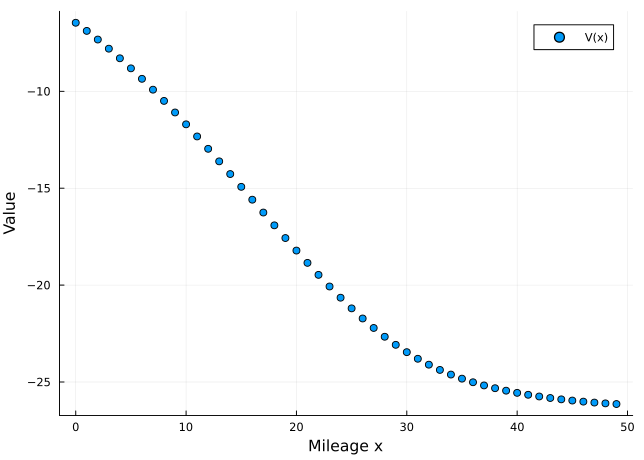

In [1]:
V = zeros(S)
dist = 1.0
niter = 0
while dist > 1e-10
    V_new = iterateBellman(m, V, F0, F1)
    dist = norm(V .- V_new, Inf)
    V = V_new
    niter += 1
end
println("Converged in $niter iterations.")

scatter(x̄, V, label="V(x)", xlabel="Mileage x", ylabel="Value",
        legend=:topright)

$V$ is decreasing in mileage: higher mileage means higher costs ahead.

**(c)** Wrap-up.

In [1]:
function solveVan(m::VanModel)
    (; β, RC, c, θ₃, S) = m
    F0, F1 = buildTransition(θ₃, S)
    V = solveBellman(m, F0, F1)
    v_keep = -c .+ β .* (F0 * V)
    v_replace = (-RC) .+ β .* (F1 * V)
    P_rep = 1.0 ./ (1.0 .+ exp.(v_keep .- v_replace))
    return (V=V, P=P_rep, v_keep=v_keep, v_replace=v_replace)
end

sol_true = solveVan(m)

(V = [-6.462163470274521, -6.882021658862709, -7.328300586545334, -7.799915705907838, -8.295712033211094, -8.814459574285776, -9.354848453734313, -9.915483728510482, -10.494879866035765, -11.091454866348894  …  -25.560338129408724, -25.659696105294408, -25.747814828048224, -25.82610110198126, -25.895749716511915, -25.95776091599707, -26.012904822968455, -26.06168052607442, -26.103337212439794, -26.13693236606075], P = [2.0611536181902037e-9, 3.136551736739318e-9, 4.900822024536826e-9, 7.853961628297893e-9, 1.2894674514815564e-8, 2.16620512411494e-8, 3.718668690565402e-8, 6.514308075665186e-8, 1.1627780871889814e-7, 2.1114756114281757e-7  …  0.40582820759598554, 0.448221671251216, 0.48951085366880615, 0.5293727995099233, 0.5675571920147976, 0.603866243736484, 0.6381010329192388, 0.6699963956347412, 0.6984956975251491, 0.722360392330501], v_keep = [-6.462163472430172, -6.88202166209371, -7.328300591540564, -7.799915713856175, -8.295712046200123, -8.814459596042173, -9.35484849101535, -9.

**(d)** Compare quadratic-cost replacement probability with the
lecture’s linear-cost case ($\theta_1 = 0.04$).


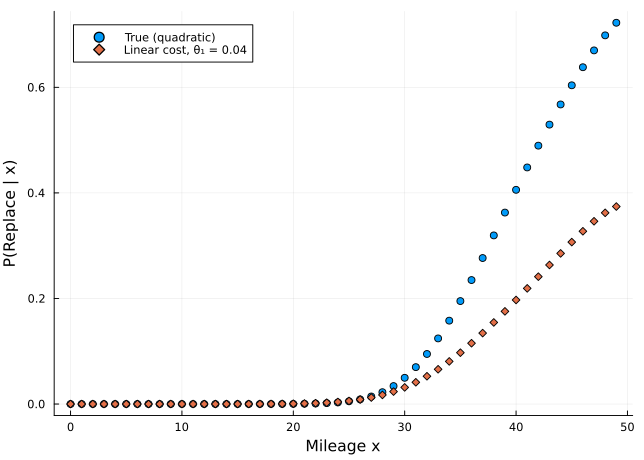

In [1]:
# Lecture-style linear-cost model (we'll reuse this in Problem 5)
@kwdef struct RustModel
    β::Float64 = 0.95
    S::Int = 50
    RC::Float64 = 20.0
    θ₁::Float64 = 0.04
    θ₃::Vector{Float64} = [0.36, 0.48, 0.16]
    x̄::Vector{Float64} = Float64.(0:S-1)
    c::Vector{Float64} = θ₁ .* x̄
end

function iterateBellman(m::RustModel, V, F0, F1)
    (; β, RC, c) = m
    v_keep = -c .+ β .* (F0 * V)
    v_replace = (-RC) .+ β .* (F1 * V)
    vmax = max.(v_keep, v_replace)
    return vmax .+ log.(exp.(v_keep .- vmax) .+ exp.(v_replace .- vmax))
end

function solveBellman(m::RustModel, F0, F1; tol=1e-10)
    V = zeros(m.S); dist = 1.0
    while dist > tol
        V_new = iterateBellman(m, V, F0, F1)
        dist = norm(V .- V_new, Inf); V = V_new
    end
    return V
end

function solveRust(m::RustModel)
    (; β, RC, c, θ₃, S) = m
    F0, F1 = buildTransition(θ₃, S)
    V = solveBellman(m, F0, F1)
    v_keep = -c .+ β .* (F0 * V)
    v_replace = (-RC) .+ β .* (F1 * V)
    P_rep = 1.0 ./ (1.0 .+ exp.(v_keep .- v_replace))
    return (V=V, P=P_rep, v_keep=v_keep, v_replace=v_replace)
end

sol_linbench = solveRust(RustModel())          # lecture default θ₁ = 0.04

scatter(x̄, sol_true.P, label="True (quadratic)", markersize=4,
        xlabel="Mileage x", ylabel="P(Replace | x)", legend=:topleft)
scatter!(x̄, sol_linbench.P, label="Linear cost, θ₁ = 0.04",
         markersize=4, markershape=:diamond)

The two curves agree at low mileage but start diverging significantly at
high mileage. This is because the linear approximation significantly
under-states the true cost at high mileage. The maintanence costs at
high mileage are the most relevant for the replacements decision.

# Simulating Data

## Problem 3: Generating a Panel

**(a)** Simulator identical to lecture (state evolves the same way; only
the cost function changed).

In [1]:
function simulateVan(P_rep, θ₃, S, T; seed=42)
    Random.seed!(seed)
    x_sim = zeros(Int, T)
    d_sim = zeros(Int, T)
    x_sim[1] = 1
    for t in 1:T
        d_sim[t] = rand() < P_rep[x_sim[t]] ? 1 : 0
        if t < T
            Δ = rand(Categorical(θ₃)) - 1
            if d_sim[t] == 1
                x_sim[t+1] = min(1 + Δ, S)
            else
                x_sim[t+1] = min(x_sim[t] + Δ, S)
            end
        end
    end
    return x_sim, d_sim
end

simulateVan (generic function with 1 method)

**(b)** Baseline simulation.

Replacement rate:   0.0236
Mean mileage state: 18.4


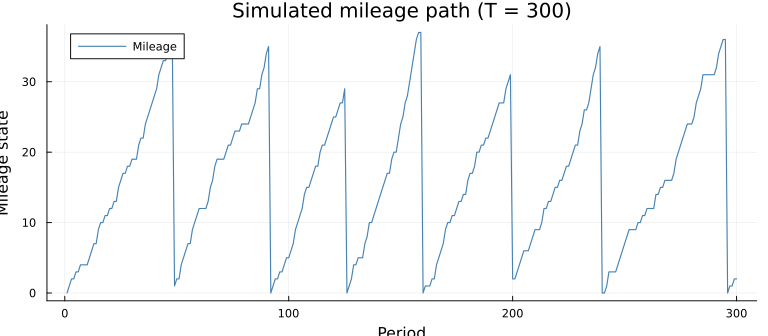

In [1]:
T = 50_000
x_sim, d_sim = simulateVan(sol_true.P, θ₃, S, T)
println("Replacement rate:   ", round(mean(d_sim), digits=4))
println("Mean mileage state: ", round(mean(x_sim), digits=2))

plot(x̄[x_sim[1:300]], linewidth=1.2, color=:steelblue, label="Mileage",
     title="Simulated mileage path (T = 300)", xlabel="Period",
     ylabel="Mileage state", size=(800, 350))

# NFXP — Correctly Specified

## Problem 4: Recovering the Quadratic Cost

**(a)** Estimate $\hat\theta_3$ from observed increments.

In [1]:
counts = zeros(3)
for t in 1:T-1
    if d_sim[t] == 0 && x_sim[t] <= S - 2
        Δ = x_sim[t+1] - x_sim[t]
        counts[Δ + 1] += 1
    elseif d_sim[t] == 1
        Δ = x_sim[t+1] - 1
        counts[Δ + 1] += 1
    end
end
θ₃_hat = counts ./ sum(counts)
println("True θ₃:      ", round.(θ₃, digits=3))
println("Estimated θ₃: ", round.(θ₃_hat, digits=3))

True θ₃:      [0.36, 0.48, 0.16]
Estimated θ₃: [0.356, 0.482, 0.163]

**(b)** NFXP objective: two parameters, $(RC, \theta_2)$.

In [1]:
function nfxpObjectiveQuad(params, x_data, d_data, β, θ₃_hat, S)
    RC_e, θ₂_e = params
    if RC_e < 0 || θ₂_e < 0
        return 1e10
    end
    m_try = VanModel(β=β, S=S, RC=RC_e, θ₂=θ₂_e, θ₃=θ₃_hat)
    sol = solveVan(m_try)
    ll = 0.0
    for t in eachindex(d_data)
        i = x_data[t]
        ll += d_data[t]       * log(max(sol.P[i],     1e-15)) +
              (1 - d_data[t]) * log(max(1 - sol.P[i], 1e-15))
    end
    return -ll
end

nfxpObjectiveQuad (generic function with 1 method)

**(c)** Optimize.

In [1]:
result_q = optimize(
    p -> nfxpObjectiveQuad(p, x_sim, d_sim, β, θ₃_hat, S),
    [15.0, 0.001],
    NelderMead(),
    Optim.Options(iterations=5000)
)
RC_q, θ₂_q = Optim.minimizer(result_q)

@printf("%-10s %12s %12s\n", "Parameter", "True", "Estimated")
@printf("%-10s %12.4f %12.4f\n", "RC", m.RC, RC_q)
@printf("%-10s %12.6f %12.6f\n", "θ₂", m.θ₂, θ₂_q)

Parameter          True    Estimated
RC              20.0000      20.2097
θ₂             0.001078     0.001096

Both parameters recovered close to the truth. The NFXP works as expected
when the functional form is correct.

**(d)** Implied vs. true replacement probability.


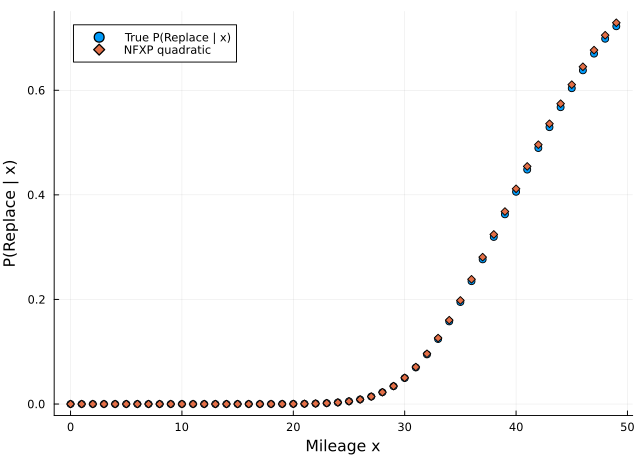

In [1]:
m_q = VanModel(RC=RC_q, θ₂=θ₂_q, θ₃=θ₃_hat)
sol_q = solveVan(m_q)

scatter(x̄, sol_true.P, label="True P(Replace | x)", markersize=4,
        xlabel="Mileage x", ylabel="P(Replace | x)", legend=:topleft)
scatter!(x̄, sol_q.P, label="NFXP quadratic", markersize=4,
         markershape=:diamond)

Near-perfect overlap.

# NFXP — Misspecified

## Problem 5: What Happens When We Force a Linear Cost

**(a)** Misspecified objective: build a `RustModel` (linear cost from
lecture) at each candidate $(RC, \theta_1)$.

In [1]:
function nfxpObjectiveLin(params, x_data, d_data, β, θ₃_hat, S)
    RC_e, θ₁_e = params
    if RC_e < 0 || θ₁_e < 0
        return 1e10
    end
    m_try = RustModel(β=β, S=S, RC=RC_e, θ₁=θ₁_e, θ₃=θ₃_hat)
    sol = solveRust(m_try)
    ll = 0.0
    for t in eachindex(d_data)
        i = x_data[t]
        ll += d_data[t]       * log(max(sol.P[i],     1e-15)) +
              (1 - d_data[t]) * log(max(1 - sol.P[i], 1e-15))
    end
    return -ll
end

nfxpObjectiveLin (generic function with 1 method)

**(b)** Estimate.

In [1]:
result_l = optimize(
    p -> nfxpObjectiveLin(p, x_sim, d_sim, β, θ₃_hat, S),
    [15.0, 0.03],
    NelderMead(),
    Optim.Options(iterations=5000)
)
RC_l, θ₁_l = Optim.minimizer(result_l)

@printf("%-12s %14s\n", "Parameter", "Estimate")
@printf("%-12s %14.4f\n", "RC (linear)", RC_l)
@printf("%-12s %14.4f\n", "θ₁ (linear)", θ₁_l)
println()
println("Lecture / OLS-fit benchmark θ₁ᴸⁱⁿ ≈ ", round(sum(x̄ .* c) / sum(x̄ .^ 2), digits=4))
println("True RC = ", m.RC)

Parameter          Estimate
RC (linear)         30.9939
θ₁ (linear)          0.0723

Lecture / OLS-fit benchmark θ₁ᴸⁱⁿ ≈ 0.04
True RC = 20.0

The misspecified $\hat\theta_1^{\text{lin}}$ lands away from
$\theta_1^{\text{lin}} \approx 0.04$. In order to match the chices at
high mileage, the estimator has to raise maintence costs. To insure that
the engine isn’t replaced too early replacement costs have to be raised
as well.

## Problem 6: Comparing Implied Choice Probabilities

**(a)** Three-curve plot.


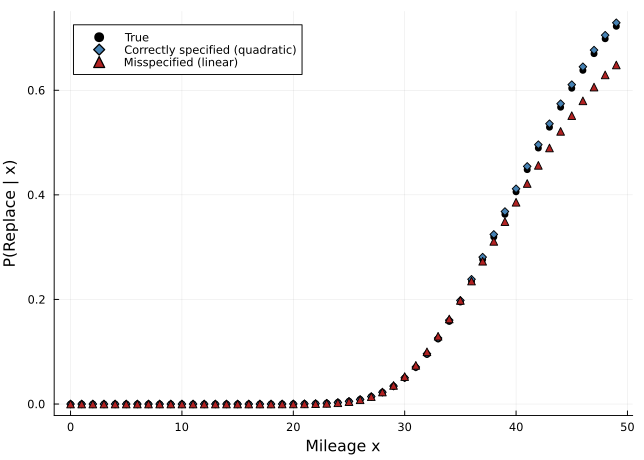

In [1]:
m_l = RustModel(RC=RC_l, θ₁=θ₁_l, θ₃=θ₃_hat)
sol_l = solveRust(m_l)

scatter(x̄, sol_true.P, label="True", markersize=4, color=:black,
        xlabel="Mileage x", ylabel="P(Replace | x)", legend=:topleft)
scatter!(x̄, sol_q.P, label="Correctly specified (quadratic)",
         markersize=4, markershape=:diamond, color=:steelblue)
scatter!(x̄, sol_l.P, label="Misspecified (linear)",
         markersize=4, markershape=:utriangle, color=:firebrick)

**(b)** The linear cost does good job at matching the replacement
probabilities at low and medium mileage. This is where most of the
replacement decisions are made. At high mileage the linear cost
significantly under-states the true cost, so the replacement
probabilities are too low.

**(c)** Counterfactual: a 30% subsidy lowers $RC$ to $0.7 \cdot RC$
under each model.


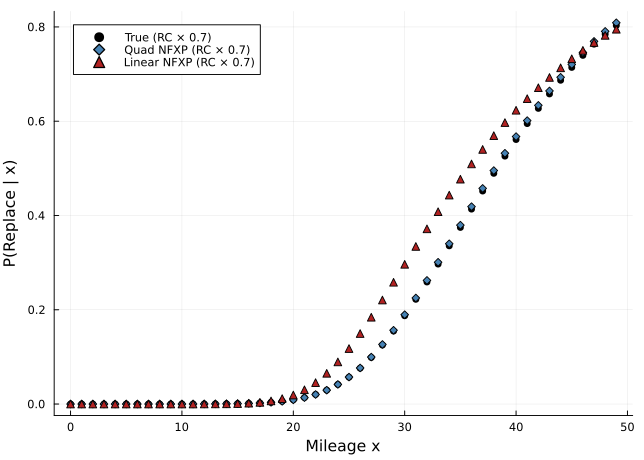

In [1]:
P_true_cf = solveVan(VanModel(RC=0.7*m.RC)).P
P_q_cf    = solveVan(VanModel(RC=0.7*RC_q, θ₂=θ₂_q, θ₃=θ₃_hat)).P
P_l_cf    = solveRust(RustModel(RC=0.7*RC_l, θ₁=θ₁_l, θ₃=θ₃_hat)).P

scatter(x̄, P_true_cf, label="True (RC × 0.7)", markersize=4, color=:black,
        xlabel="Mileage x", ylabel="P(Replace | x)", legend=:topleft)
scatter!(x̄, P_q_cf, label="Quad NFXP (RC × 0.7)", markersize=4,
         markershape=:diamond, color=:steelblue)
scatter!(x̄, P_l_cf, label="Linear NFXP (RC × 0.7)", markersize=4,
         markershape=:utriangle, color=:firebrick)

The correctly specified estimator’s counterfactual curve sits almost
exactly on top of the truth. The misspecified linear estimator’s curve
has the wrong *shape*. The replacement probabilities grow too quickly,
due to the misspecified linear costs having higher maintence costs at
lower mileage.